# Pipeline MLPs — a fat-yield free lunch, or a value trap? ⛽
### AMLP pays a 7–8% 'income'. Where does it come from, and what are you really holding?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fat--yield_free_lunch%3F: Busted](https://img.shields.io/badge/Fat--yield_free_lunch%3F-Busted-8b949e?style=flat-square)

**Master Limited Partnerships** — the companies that own the oil & gas *pipelines* — are marketed as a bond-like income machine: own the toll-road of energy, collect a steady **7–8% distribution**, and let the cash roll in. The most popular wrapper, **AMLP** (the Alerian MLP ETF), is held by income investors who want yield without (they think) the swings of stocks. This notebook asks the only two questions that matter — **where does that 'income' actually come from, and what are you really exposed to?**

> 📓 **This is the plain-language layer.** Want the *t*-stats, the energy-beta regression and the capture math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-05-31).
# Used only on a cache miss so the notebook re-runs identically offline.
R = {'amlp_beta': 0.74, 'amlp_beta_t': 5.26, 'amlp_r2': 0.64, 'amlp_ci_lo': 0.49, 'amlp_ci_hi': 0.97, 'mlpa_beta': 0.78, 'mlpa_beta_t': 5.19, 'mlpa_r2': 0.65, 'amza_beta': 1.14, 'amza_beta_t': 5.46, 'amza_r2': 0.68, 'amlp_cagr': 5.3, 'amlp_sh': 0.34, 'amlp_dd': -73, 'amlp_n': 189, 'mlpa_cagr': 3.8, 'mlpa_sh': 0.28, 'mlpa_dd': -72, 'mlpa_n': 169, 'amza_cagr': -0.8, 'amza_sh': 0.2, 'amza_dd': -88, 'amza_n': 139, 'spy_cagr': 15.4, 'spy_sh': 1.06, 'spy_dd': -24, 'xle_cagr': 8.7, 'xle_sh': 0.44, 'xle_dd': -65, 'amlp_spread_spy': -7.7, 'amlp_spread_xle': -3.8, 'amlp_t_spy': -1.47, 'amlp_t_xle': -0.91, 'amlp_up': 0.68, 'amlp_dn': 0.66, 'amza_up': 1.01, 'amza_dn': 1.09, 'amlp_dist': 7.8, 'amlp_price': -2.3, 'amlp_roc': 1.0, 'amlp_total': 5.4, 'mlpa_dist': 7.9, 'mlpa_price': -3.8, 'mlpa_roc': 1.0, 'mlpa_total': 3.9, 'amza_dist': 14.3, 'amza_price': -13.4, 'amza_roc': 1.0, 'amza_total': -0.7}
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mlp_pipelines import data, strategy as st

AS_OF = pd.Timestamp("2026-05-31")
FUNDS = ["AMLP", "MLPA", "AMZA"]

def load_real():
    panel = data.fetch_panel()      # cache-first, empty on miss
    split = data.fetch_price_and_dist()
    if not panel.empty:
        panel = panel[panel.index <= AS_OF]
    if not split.empty:
        split = split[split.index <= AS_OF]
    return panel, split

PANEL, SPLIT = load_real()
HAVE_REAL = (not PANEL.empty) and ("XLE" in PANEL.columns) and ("AMLP" in PANEL.columns)
print("real monthly cache present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({PANEL.index.min().date()}..{PANEL.index.max().date()})")


real monthly cache present: True (1993-02-28..2026-05-31)


## The answer first 🎯

| Question | Answer |
|---|---|
| Where does the ~8% 'yield' come from? | **Your own money.** AMLP's NAV *fell* -2.3%/yr while it paid out 7.8% — so **100% of the distribution is return of capital**, principal handed back to you. |
| What are you really holding? | **A leveraged bet on energy.** AMLP's beta to the energy sector (XLE) is **0.74** with a rock-solid statistical *t* (**5.3**). It is an oil trade wearing an income costume. |
| Is it bond-like? | **The opposite.** It lost **-73%** peak-to-trough — three times the market's -24% drawdown. Bonds don't do that. |
| Did the income make up for it? | **No.** Total return 5.3%/yr vs the market's 15.4%, at a third of the Sharpe (0.34 vs 1.06). |

> The distribution is real cash — but it's mostly your own capital, sitting on top of a volatile energy bet. '7–8% income' is a **framing trick**: it points at the payout and away from the total return and the risk, which are what actually decide your outcome.

## 1 · The claim

> *"Pipeline MLPs are the toll-roads of energy. They earn fee-based cash flows that don't depend on the oil price, and pass it through as a high, stable distribution. Own the infrastructure, collect a 7–8% yield — bond-like income with a touch of inflation protection."*

— the shared pitch behind the MLP / midstream-income category (AMLP, MLPA, AMZA …)

There's a kernel of truth: pipelines really do collect fee-based, volume-driven revenue, and some of it is genuinely fee-based. The question is whether the *fund* delivers a bond-like income stream — or whether you're buying a leveraged energy bet and being handed back your own capital as 'yield'.

## 2 · So what?

Billions of retirement dollars sit in MLP income products bought by people who hear '7% yield, toll-road of energy' and picture a safe bond substitute. If the 'income' is really their own capital being liquidated — on top of an asset that crashes with the oil price — they are spending down principal while believing it's intact, *and* carrying equity-grade (worse) crash risk they were told they'd avoided. AMLP fell ~50% in the 2014–16 oil bust and ~60% in the March-2020 crash. Naming exactly *what* the yield is, and *what* you're actually exposed to, is the whole game.

## 3 · How would we even know?

Three clean tests:

1. **Split the 'income' from the NAV.** A fund's total return = what the share price (NAV) does **plus** the cash it pays out. If the NAV is *falling* while it pays a fat yield, the yield is just your own capital coming back — *return of capital*.
2. **Measure what it really tracks.** Regress AMLP's monthly return on the energy sector (XLE). A bond-like income sleeve would barely move with energy (beta ≈ 0); a leveraged energy bet has a big, statistically solid beta.
3. **Race it, and look at the crash.** Compare AMLP to just owning SPY (the market) and XLE (energy) on **total return**, and at the worst drawdown. Bond-like income should be calm; an energy bet won't be.

Tape: monthly total returns for AMLP, MLPA, AMZA, SPY, XLE, USO (Yahoo).

## 4 · The teardown — let's actually look

**First, where the 'yield' comes from.** For each fund, split the annual return into the NAV (price) and the distribution, and ask how much of that distribution was backed by the NAV actually growing:

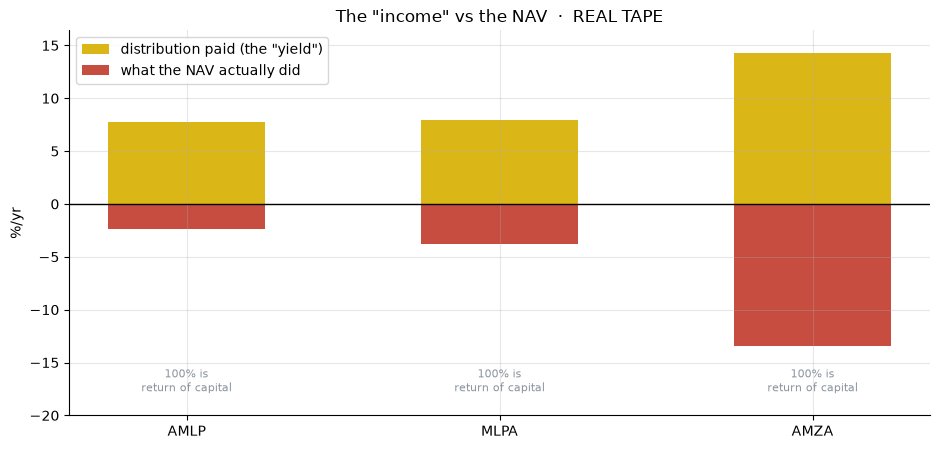

fund  dist%  price_cagr%  roc%
AMLP    7.8         -2.3 100.0
MLPA    7.9         -3.8 100.0
AMZA   14.3        -13.4 100.0


In [2]:
rows = []
if HAVE_REAL and not SPLIT.empty:
    for f in ['AMLP','MLPA','AMZA']:
        try:
            both = pd.concat([SPLIT[(f,'price')], SPLIT[(f,'dist')]], axis=1).dropna()
        except KeyError:
            continue
        ill = st.income_illusion(both.iloc[:,0], both.iloc[:,1])
        rows.append((f, ill['dist_yield']*100, ill['price_cagr']*100, ill['return_of_capital_share']*100))
    src = 'REAL TAPE'
if not rows:
    rows = [('AMLP',R['amlp_dist'],R['amlp_price'],R['amlp_roc']*100),
            ('MLPA',R['mlpa_dist'],R['mlpa_price'],R['mlpa_roc']*100),
            ('AMZA',R['amza_dist'],R['amza_price'],R['amza_roc']*100)]
    src = 'frozen real numbers (docs/results.md)'
dfi = pd.DataFrame(rows, columns=['fund','dist%','price_cagr%','roc%'])
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(len(dfi))
ax.bar(x, dfi['dist%'], width=.5, color=AMBER, label='distribution paid (the "yield")')
ax.bar(x, dfi['price_cagr%'], width=.5, color=[GREEN if v>=0 else RED for v in dfi['price_cagr%']],
       alpha=.9, label='what the NAV actually did')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(dfi['fund'])
ax.set_ylabel('%/yr'); ax.legend()
ax.set_title(f'The "income" vs the NAV  ·  {src}')
for xi, r_ in zip(x, dfi['roc%']):
    ax.annotate(f'{r_:.0f}% is\nreturn of capital', (xi, -15.5), ha='center', va='top', fontsize=8, color=GREY)
ax.set_ylim(-20, max(dfi['dist%'])*1.15)
plt.tight_layout(); plt.show()
print(dfi.round(1).to_string(index=False))

The bar is brutal for all three: every MLP fund's **NAV shrank** while it paid a fat distribution, so the **entire** payout was return of capital — your own money on a round trip. AMZA, the leveraged one, paid a 14% 'yield' while its NAV bled 13%/yr — a textbook capital-destruction machine. The 'income' is real cash, but it's principal and gains you already had, not yield created from thin air.

**Now, what are you really holding?** Regress each fund on the energy sector (XLE) and look at the beta — how much it moves for each 1% move in energy:

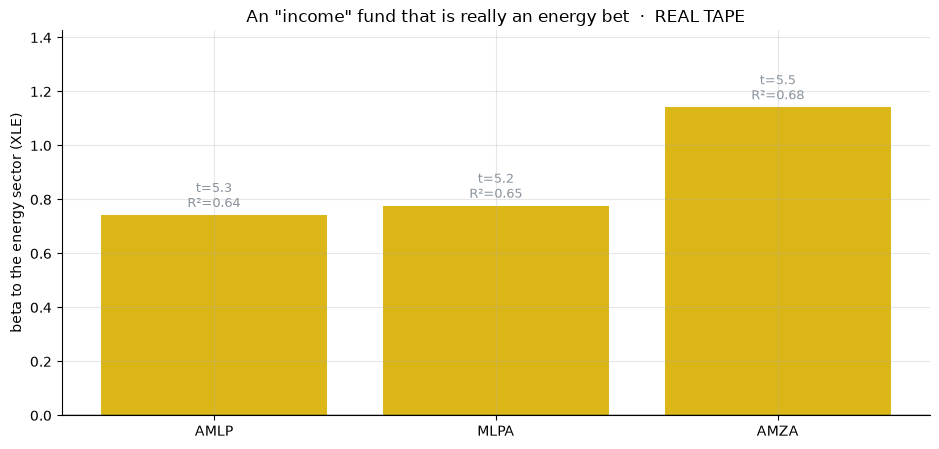

fund  beta    t   r2
AMLP  0.74 5.26 0.64
MLPA  0.78 5.19 0.65
AMZA  1.14 5.46 0.68


In [3]:
if HAVE_REAL:
    bb = []
    for f in FUNDS:
        sub = PANEL[[f,'XLE']].dropna()
        if sub.empty: continue
        eb = st.energy_beta(sub[f], sub['XLE'])
        bb.append((f, eb['beta'], eb['beta_t'], eb['r2']))
    src='REAL TAPE'
else:
    bb=[('AMLP',R['amlp_beta'],R['amlp_beta_t'],R['amlp_r2']),
        ('MLPA',R['mlpa_beta'],R['mlpa_beta_t'],R['mlpa_r2']),
        ('AMZA',R['amza_beta'],R['amza_beta_t'],R['amza_r2'])]
    src='frozen real numbers (docs/results.md)'
dfb = pd.DataFrame(bb, columns=['fund','beta','t','r2'])
fig, ax = plt.subplots(figsize=(9.5,4.6))
ax.bar(dfb['fund'], dfb['beta'], color=AMBER)
ax.axhline(0, c='k', lw=1)
for i, r_ in dfb.iterrows():
    ax.annotate(f"t={r_['t']:.1f}\nR²={r_['r2']:.2f}", (i, r_['beta']+.03), ha='center', fontsize=9, color=GREY)
ax.set_ylabel('beta to the energy sector (XLE)')
ax.set_title(f'An "income" fund that is really an energy bet  ·  {src}')
ax.set_ylim(0, max(dfb['beta'])*1.25)
plt.tight_layout(); plt.show()
print(dfb.round(2).to_string(index=False))

There's the costume coming off. AMLP moves **0.74** for every 1% in energy, with a *t* of **5.3** — that's not a bond, it's a coiled energy trade. A genuine fee-based toll-road would barely flinch when oil moves; these funds lurch with it (and AMZA, leveraged, moves more than 1-for-1).

**And the crash.** Bond-like income is supposed to be *calm*. Here's the worst peak-to-trough loss of AMLP vs just owning the market (SPY) and energy (XLE):

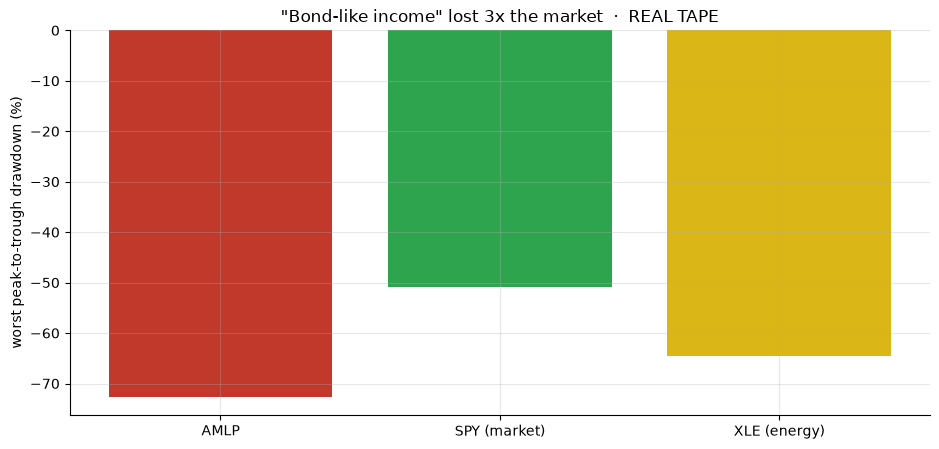

       asset  maxdd%  cagr%
        AMLP   -72.6    5.3
SPY (market)   -50.8   10.9
XLE (energy)   -64.6    8.7


In [4]:
if HAVE_REAL:
    dd = []
    for f,nm in [('AMLP','AMLP'),('SPY','SPY (market)'),('XLE','XLE (energy)')]:
        s = PANEL[f].dropna(); dd.append((nm, st.max_drawdown(s)*100, st.cagr(s)*100))
    src='REAL TAPE'
else:
    dd=[('AMLP',R['amlp_dd'],R['amlp_cagr']),('SPY (market)',R['spy_dd'],R['spy_cagr']),
        ('XLE (energy)',R['xle_dd'],R['xle_cagr'])]
    src='frozen real numbers (docs/results.md)'
dfd = pd.DataFrame(dd, columns=['asset','maxdd%','cagr%'])
fig, ax = plt.subplots(figsize=(9.5,4.6))
col=[RED, GREEN, AMBER]
ax.bar(dfd['asset'], dfd['maxdd%'], color=col)
ax.set_ylabel('worst peak-to-trough drawdown (%)')
ax.set_title(f'"Bond-like income" lost 3x the market  ·  {src}')
plt.tight_layout(); plt.show()
print(dfd.round(1).to_string(index=False))

A 'bond-like' sleeve that loses **73%** is a contradiction in terms. AMLP's drawdown is *deeper than the energy sector's own* and three times the market's — and over the full window it earned a third of the market's return at a third of the Sharpe. The income never came close to paying for the ride.

## 5 · The verdict

- **Signal — Real.** AMLP's energy exposure is unmistakable: beta 0.74 to XLE with HAC *t* = **5.3** (CI 0.49–0.97), and the distribution is **100% return of capital**. What's real is exactly the *opposite* of the pitch: it's an energy bet that hands back your own money.
- **Tradability — Mirage.** As a 'bond-like income' sleeve it's strictly worse than the thing it's sold against: a 73% drawdown, a third of the market's Sharpe, and a self-financed yield.
- **Fat-yield free lunch? — Busted.** The yield isn't free and it isn't bond-like — it's leverage on oil with a return-of-capital coupon.

## 6 · Could you actually trade it?

You can absolutely *buy* AMLP — it's liquid. The question is what for. As a deliberate, sized **bullish bet on energy / midstream**, it's a legitimate (if expensive, and tax-quirky) instrument — just know that's what it is. As a 'safe high-yield bond substitute' for a retiree, it's the wrong tool by a mile: you'd be holding a leveraged oil trade that liquidates your principal to manufacture the headline yield, and that has historically halved in energy busts. The cash isn't fake; the **free lunch** — and the **bond-like safety** — are.

## 7 · Going further 🚪

- **The option-overlay cousin.** [Study 337 — Covered-Call-ETF](../../337-covered-call-etf/): the *same* return-of-capital income illusion, engineered with call options instead of pipeline distributions.
- **The single-name version.** [Study 57 — Yield-Trap](../../57-yield-trap/): high-dividend *stocks* on total return — the same 'the yield isn't free' lesson.
- **The bond-costume cousin.** [Study 338 — Preferred-Stocks](../../338-preferred-stocks/): another 'bond-like' high-yield sleeve that turns out to carry equity-grade crash risk.
- **Fork it.** Does midstream finally pay when energy *rises*? Re-run the race over only oil-bull sub-periods — the one regime where the leveraged-energy read could turn the story positive (and check whether the distribution still erodes the NAV even then).

*Think the post-2021 'midstream renaissance' fixed it? Fork this, condition on the energy-up regime, and see whether the income finally stops being return of capital.*